In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import itertools
from sklearn.metrics.cluster import adjusted_mutual_info_score, adjusted_rand_score
from scipy import stats
from scipy.stats import pearsonr, kruskal, chi2_contingency, mannwhitneyu, linregress
import seaborn as sns
from ptitprince import PtitPrince as pt
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import multivariate_logrank_test
from lifelines.plotting import add_at_risk_counts
from sklearn.utils.class_weight import compute_class_weight
from pandas.api.types import is_numeric_dtype
from statsmodels.stats.multitest import multipletests
import statsmodels
from scipy.cluster.hierarchy import fcluster
import forestplot as fp
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import KBinsDiscretizer
from matplotlib import rcParams

In [4]:
from general_functions import clinical_enrichment, calculate_stability_metrics

In [5]:
RANDOM_STATE = 42
n_clusters = 2

In [6]:
sns.set_theme(style='ticks')
rcParams.update({
    'font.size': 11,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica'],
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'axes.edgecolor': 'black',
    'axes.linewidth': 0.8,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'legend.fontsize': 11,
    'legend.frameon': False,
    'savefig.format': 'svg',
    'savefig.dpi': 300,  # Still useful for rasterized elements
    'figure.dpi': 100,
    'figure.figsize': (3.5, 2.5),  # Approx. half-column width
    'figure.constrained_layout.use': True,
    'svg.fonttype': 'none',  # Keep text as editable text (not paths)
    'axes.spines.top': False,
    'axes.spines.right': False,
})

In [7]:
import warnings
warnings.filterwarnings("ignore")
final_clusters = pd.read_csv('patient_clusters.csv', index_col=0).T.to_dict('list')
final_clusters = {k: [x for x in v if pd.notna(x)] for k, v in final_clusters.items()}
clinical_data_file = pd.read_csv('TCGA_raw_data/cancer_data_PAAD_clinical_data.tsv', sep='\t', header=0)

In [8]:
clinical_data = clinical_data_file[['Patient ID', 'Mutation Count', 'Fraction Genome Altered', 'Diagnosis Age', 'Sex', 'Race Category', 
                                    'Adjuvant Postoperative Targeted Therapy Administered Indicator', 'Alcohol History Documented', 'Tumor resected max dimension',
                                    'American Joint Committee on Cancer Metastasis Stage Code', 'American Joint Committee on Cancer Tumor Stage Code',
                                    'Chronic Pancreatitis Personal Medical History Indicator', 'Did patient start adjuvant postoperative radiotherapy?', 
                                    'Disease Free Status', 'Family History of Cancer', 'Neoplasm Disease Lymph Node Stage American Joint Committee on Cancer Code', 
                                    'Neoplasm Disease Stage American Joint Committee on Cancer Code', 'Neoplasm Histologic Grade', 'TMB (nonsynonymous)',
                                    'New Neoplasm Event Post Initial Therapy Indicator', 'Overall Survival (Months)', 'Overall Survival Status', 'Disease Free (Months)', 
                                    'Participant Personal Medical History Diabetes Mellitus Ind-3', 'Patient Primary Tumor Site', 'Prior Cancer Diagnosis Occurence', 
                                    'Surgical Margin Resection Status', 'Patient Smoking History Category', 'Person Neoplasm Status', 'Primary Therapy Outcome Success Type']]
clinical_data['Overall Survival Status'] = clinical_data['Overall Survival Status'].str.split(':').str[0].astype(int)
clinical_data['Patient Smoking History Category'] = (clinical_data['Patient Smoking History Category']
                                                         .where(clinical_data['Patient Smoking History Category'].isna(), 
                                                                clinical_data['Patient Smoking History Category'].astype(float).astype(str)))
clinical_data.set_index('Patient ID', inplace=True)
clinical_data['Cluster'] = None
for cluster_num, patients in final_clusters.items():
    cluster_label = 1 if int(cluster_num.split('_')[-1]) == 1 else 2
    clinical_data.loc[clinical_data.index.isin(patients), 'Cluster'] = cluster_label
clinical_data.dropna(subset=['Cluster'], inplace=True)

# Minimal biomarker panel

From the previous results, there are no differences in survival. However, the clusters are always very consistent, which could indicate that there is some underlying information that might be helpful or an indicator for pancreatic cancer. For that reason, we will check for biomarkers using a cross-validation and feature selection approach. Four methods will be used.

In [9]:
survival_data = clinical_data[['Overall Survival Status', 'Overall Survival (Months)']]
recurrence_data = clinical_data[['Disease Free Status', 'Disease Free (Months)']]
recurrence_data.dropna(inplace=True)
recurrence_data['Disease Free Status'] = recurrence_data['Disease Free Status'].str.split(':').str[0].astype(int)

### ABESS analysis

In [10]:
from abess import LogisticRegression
from contextlib import contextmanager
from sklearn.base import BaseEstimator, TransformerMixin
import copy

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
random_numbers = np.random.randint(0, 100 + 1, size=10).tolist()
months = [6, 12, 18, 24, 36, 60]

In [11]:
@contextmanager
def fixed_seed(seed):
    state = np.random.get_state()
    np.random.seed(seed)
    try:
        yield
    finally:
        np.random.set_state(state)
        
class ABESSClassif(LogisticRegression):
    def __init__(self, p=None, random_state=None):
        self.p = p
        self.random_state = random_state
        with fixed_seed(self.random_state):
            super().__init__(support_size=p)

    def fit(self, X, y=None):
        with fixed_seed(self.random_state):
            super().fit(X=X, y=y)
        coef = self.coef_
        if coef.ndim == 1:
            coef = coef[np.newaxis, :]
        features = X.columns[np.where(np.any(coef != 0, axis=0))[0]]
        self.features_ = list(set(features))
        if self.p is not None:
            assert self.p == len(self.features_)
        return self

    def transform(self, X):
        return X[self.features_]

class MultiModalIFABESS(BaseEstimator, TransformerMixin):
    def __init__(self, random_state=None):
        self.random_state = random_state

    def fit(self, Xs, y):
        self.models_per_view_ = []
        self.selected_columns_per_view_ = []
        for X in Xs:
            model = ABESSClassif(random_state=self.random_state)
            model.fit(X, y)
            coef = model.coef_.ravel()
            support = np.where(coef != 0)[0]
            selected_cols = X.columns[support].tolist()
            self.models_per_view_.append(model)
            self.selected_columns_per_view_.append(selected_cols)
        selected_Xs = []
        for X, cols in zip(Xs, self.selected_columns_per_view_):
            selected_Xs.append(X[cols])
        X_combined = pd.concat(selected_Xs, axis=1)
        self.final_model_ = ABESSClassif(random_state=self.random_state)
        self.final_model_.fit(X_combined, y)
        coef_final = self.final_model_.coef_.ravel()
        mask = np.where(coef_final != 0)[0]
        self.features_ = X_combined.columns[mask].tolist()
        return self

    def transform(self, Xs):
        selected_Xs = []
        for X, cols in zip(Xs, self.selected_columns_per_view_):
            selected_Xs.append(X[cols])
        X_combined = pd.concat(selected_Xs, axis=1)
        return X_combined[self.features_]


class SplitMultiModalWrapper(BaseEstimator, TransformerMixin):
    def __init__(self, selector, cna_cols, methyl_cols):
        self.selector = selector
        self.cna_cols = cna_cols
        self.methyl_cols = methyl_cols

    def fit(self, X, y=None):
        X_cna = X[self.cna_cols]
        X_methyl = X[self.methyl_cols]
        X_list = [X_cna, X_methyl]
        self.selector.fit(X_list, y)
        return self

    def transform(self, X):
        X_cna = X[self.cna_cols]
        X_methyl = X[self.methyl_cols]
        X_list = [X_cna, X_methyl]        
        return self.selector.transform(X_list)

MCC score: 0.9052, standard deviation: 0.1049
Selected methylation features: ['cg06785999', 'cg00839579', 'cg07095230']
Matthews Correlation Coefficient: 0.6831, standard deviation: 0.2205
Out-of-bag (OOB) score: 0.9673
PLOTS (SURVIVAL):
Overall:
cg06785999: p-val = 0.31, HR = 1.84
cg00839579: p-val = 0.19, HR = 1.84
cg07095230: p-val = 0.15, HR = 2.33


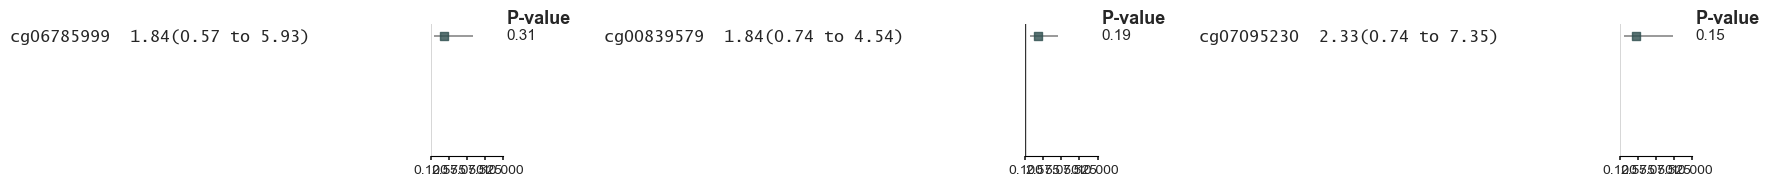

6 months:
cg06785999: p-val = 0.07, HR = 9.29
cg00839579: p-val = 0.03, HR = 9.95
cg07095230: p-val = 0.30, HR = 3.64


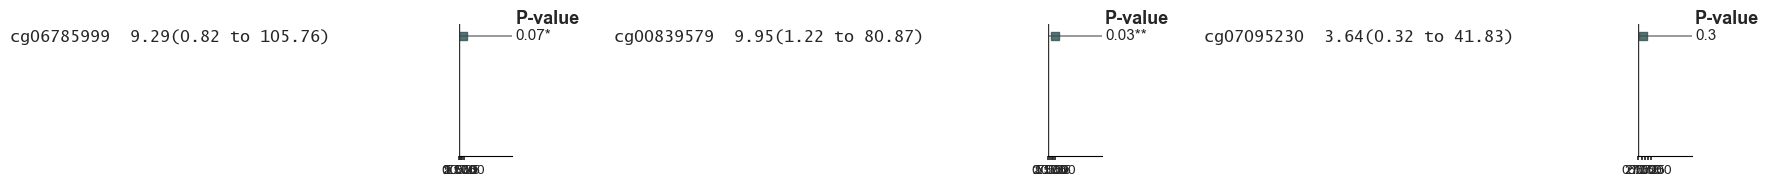

12 months:
cg06785999: p-val = 0.38, HR = 2.08
cg00839579: p-val = 0.06, HR = 3.78
cg07095230: p-val = 0.22, HR = 2.84


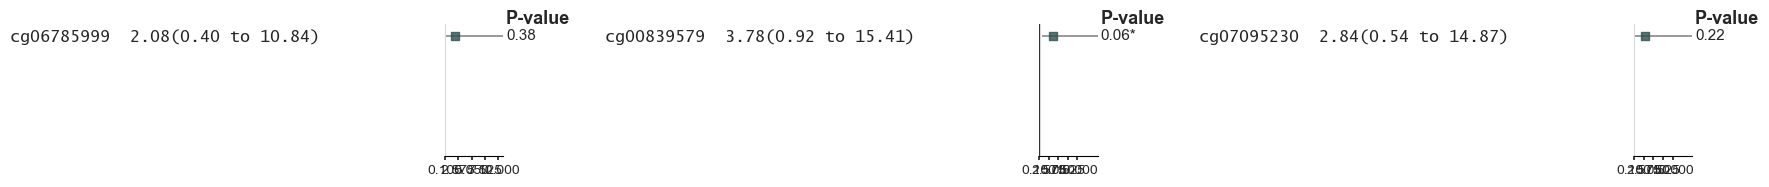

18 months:
cg06785999: p-val = 0.11, HR = 2.87
cg00839579: p-val = 0.03, HR = 3.35
cg07095230: p-val = 0.04, HR = 4.00


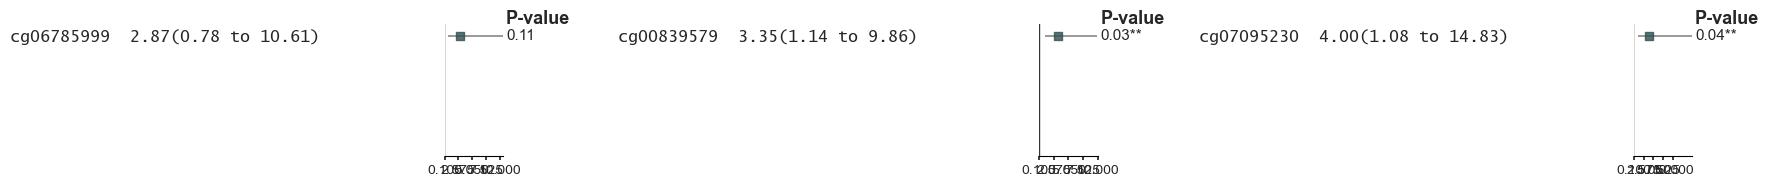

24 months:
cg06785999: p-val = 0.38, HR = 1.71
cg00839579: p-val = 0.25, HR = 1.75
cg07095230: p-val = 0.16, HR = 2.33


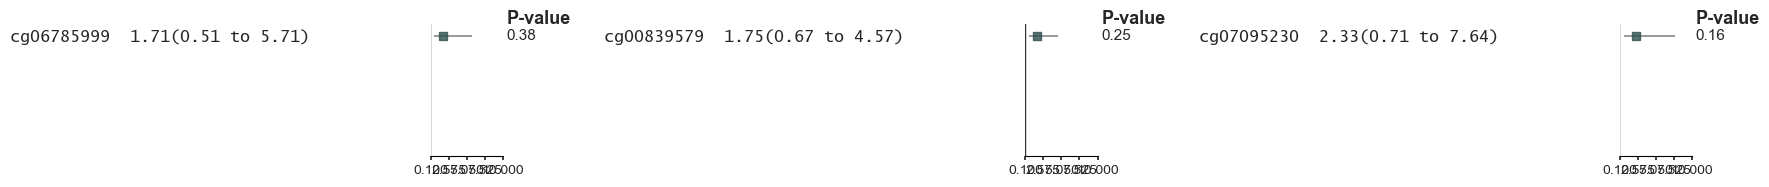

36 months:
cg06785999: p-val = 0.31, HR = 1.84
cg00839579: p-val = 0.19, HR = 1.86
cg07095230: p-val = 0.14, HR = 2.40


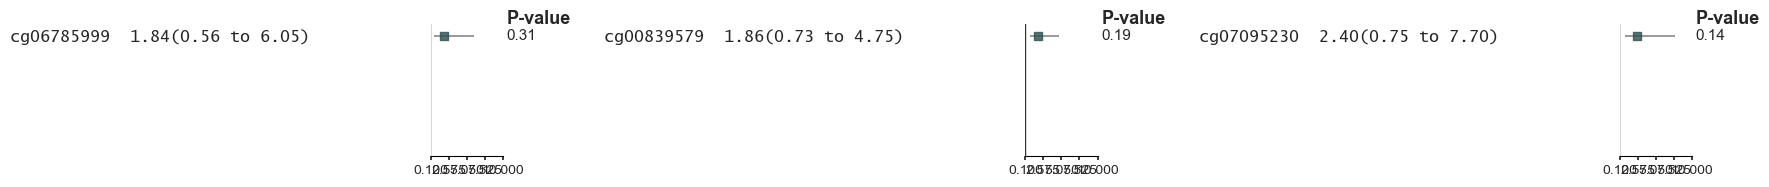

60 months:
cg06785999: p-val = 0.33, HR = 1.80
cg00839579: p-val = 0.22, HR = 1.77
cg07095230: p-val = 0.17, HR = 2.22


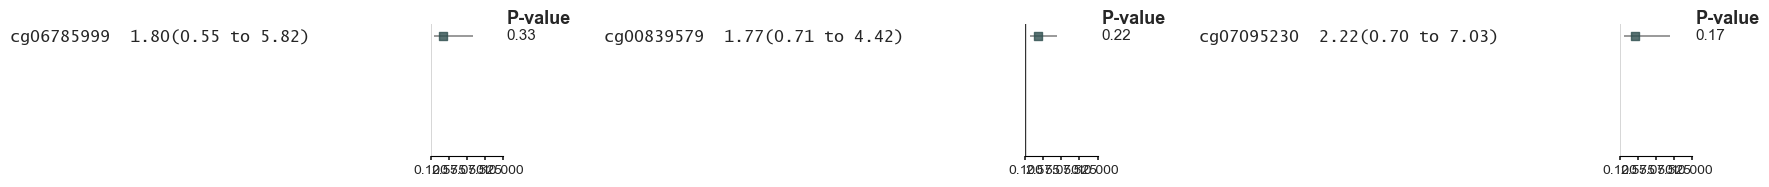

PLOTS (RECURRENCE):
Overall:
cg06785999: p-val = 0.07, HR = 3.51
cg00839579: p-val = 0.48, HR = 1.44
cg07095230: p-val = 0.12, HR = 2.80


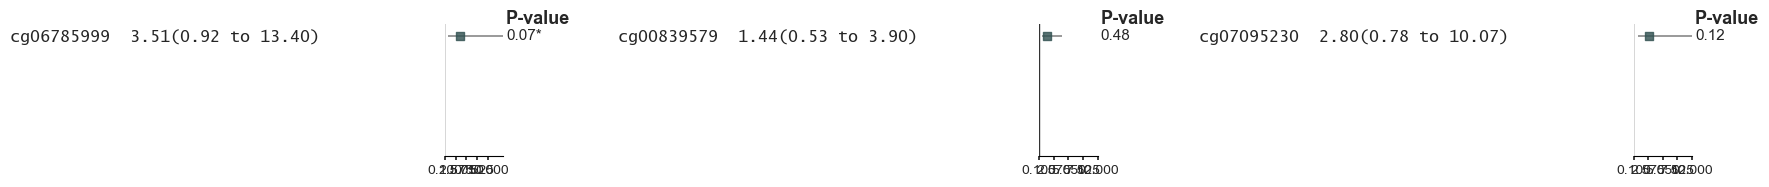

6 months:
cg06785999: p-val = 0.23, HR = 4.34
cg00839579: p-val = 0.31, HR = 2.76
cg07095230: p-val = 0.10, HR = 7.55


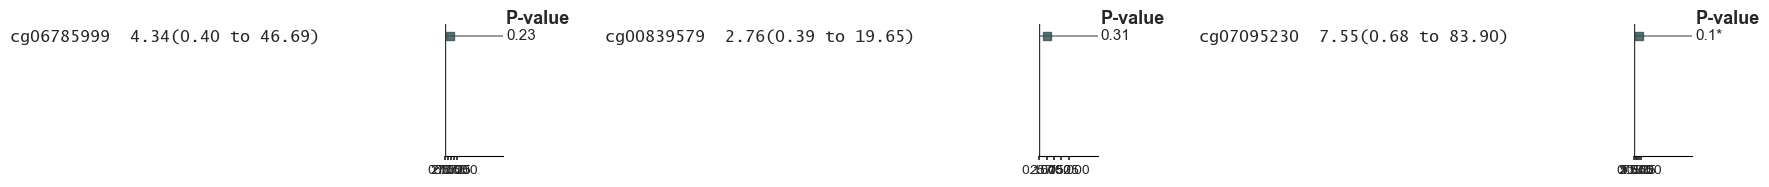

12 months:
cg06785999: p-val = 0.05, HR = 5.62
cg00839579: p-val = 0.18, HR = 2.45
cg07095230: p-val = 0.05, HR = 5.06


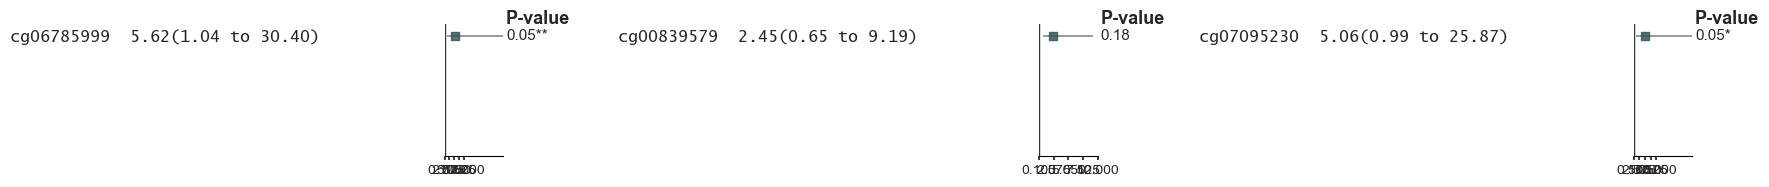

18 months:
cg06785999: p-val = 0.03, HR = 5.11
cg00839579: p-val = 0.20, HR = 2.06
cg07095230: p-val = 0.02, HR = 5.32


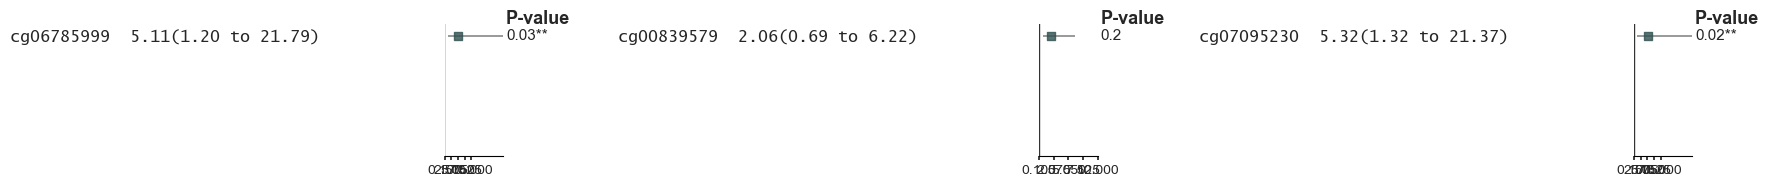

24 months:
cg06785999: p-val = 0.01, HR = 5.77
cg00839579: p-val = 0.22, HR = 1.94
cg07095230: p-val = 0.03, HR = 4.22


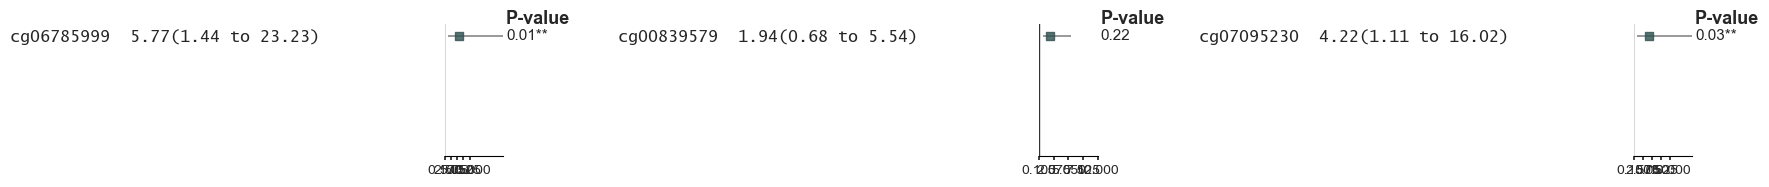

36 months:
cg06785999: p-val = 0.03, HR = 4.47
cg00839579: p-val = 0.27, HR = 1.77
cg07095230: p-val = 0.06, HR = 3.52


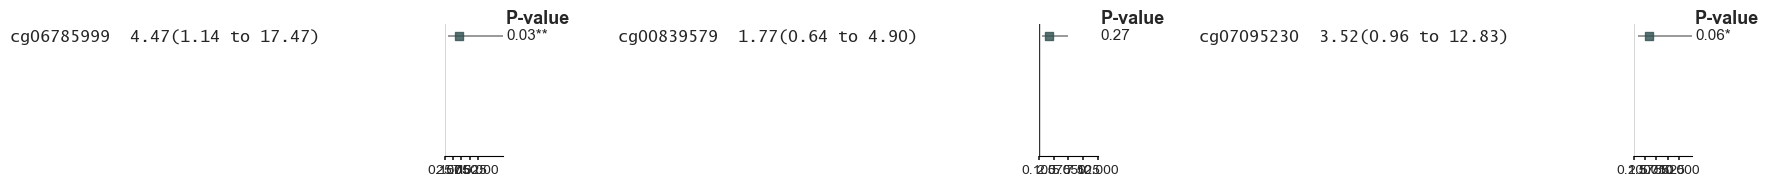

60 months:
cg06785999: p-val = 0.07, HR = 3.51
cg00839579: p-val = 0.48, HR = 1.44
cg07095230: p-val = 0.12, HR = 2.80


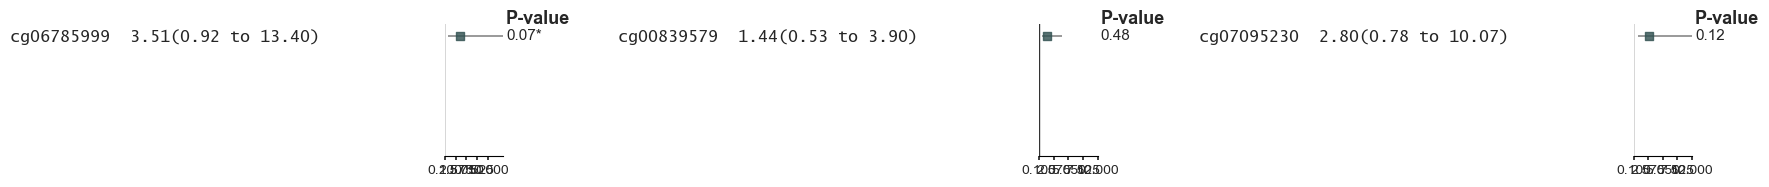

In [19]:
# METHYLATION FEATURE SELECTION
methylation_data = pd.read_csv('TCGA_processed_data/methylation_processed.csv', index_col=0)
methylation_data['Cluster'] = methylation_data.index.map(clinical_data['Cluster'])
methylation_data.dropna(subset=['Cluster'], inplace=True)
X_methyl = methylation_data.drop(columns='Cluster').astype(float)
y_methyl = methylation_data['Cluster'].astype(int)

# Matthews coefficient (all features)
crossval_methyl = cross_val_score(RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced_subsample'), 
                                  X_methyl, y_methyl, cv=skf, scoring='matthews_corrcoef')
print("MCC score: %0.4f, standard deviation: %0.4f" % (crossval_methyl.mean(), crossval_methyl.std()))

# Do ABESS on methylation features
pipeline_methyl = make_pipeline(ABESSClassif(random_state=RANDOM_STATE),
                                RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced_subsample', oob_score=True))
scores_methyl = cross_val_score(pipeline_methyl, X_methyl, y_methyl, cv=skf, scoring='matthews_corrcoef')
pipeline_methyl.fit(X_methyl, y_methyl)
features_selected_methyl = pipeline_methyl.named_steps['abessclassif'].features_
print(f"Selected methylation features: {features_selected_methyl}")
print(f"Matthews Correlation Coefficient: {scores_methyl.mean():.4f}, standard deviation: {scores_methyl.std():.4f}")
print(f"Out-of-bag (OOB) score: {pipeline_methyl.named_steps['randomforestclassifier'].oob_score_:.4f}")

features_selected_methyl = pipeline_methyl.named_steps['abessclassif'].features_
selected_methyl_data = X_methyl[features_selected_methyl]

# SURVIVAL PLOTS
cox_methyl_survival = selected_methyl_data.merge(survival_data, left_index=True, right_index=True)
print("PLOTS (SURVIVAL):")
fig, axes = plt.subplots(1, len(features_selected_methyl), figsize=(6 * len(features_selected_methyl), 2))
print("Overall:")
for i, col_idx in enumerate(features_selected_methyl):
    biomarker = col_idx
    biomarker_data = cox_methyl_survival[[biomarker, 'Overall Survival (Months)', 'Overall Survival Status']]
    cph = CoxPHFitter()
    summary = cph.fit(biomarker_data, duration_col='Overall Survival (Months)', event_col='Overall Survival Status').summary
    print(f"{biomarker}: p-val = {summary['p'].loc[biomarker]:.2f}, HR = {summary['exp(coef)'].loc[biomarker]:.2f}")
    summary.reset_index(inplace=True)
    ax = axes[i] if len(features_selected_methyl) > 1 else axes
    fp.forestplot(summary, estimate='exp(coef)', ll='exp(coef) lower 95%', hl='exp(coef) upper 95%',
        varlabel='covariate', pval='p', color_alt_rows=True, ax=ax, title=biomarker, xticks=np.linspace(0.1, 10, 5))
plt.tight_layout()
plt.show()
for time in months:
    print(f"{time} months:")
    cox_copy = cox_methyl_survival.copy()
    time_subset = cox_copy['Overall Survival (Months)'] <= time
    cox_copy.loc[~time_subset, 'Overall Survival Status'] = 0
    fig, axes = plt.subplots(1, len(features_selected_methyl), figsize=(6 * len(features_selected_methyl), 2))
    for i, col_idx in enumerate(features_selected_methyl):
        biomarker = col_idx
        biomarker_data = cox_copy[[biomarker, 'Overall Survival (Months)', 'Overall Survival Status']]
        cph = CoxPHFitter()
        summary = cph.fit(biomarker_data, duration_col='Overall Survival (Months)', event_col='Overall Survival Status').summary
        print(f"{biomarker}: p-val = {summary['p'].loc[biomarker]:.2f}, HR = {summary['exp(coef)'].loc[biomarker]:.2f}")
        summary.reset_index(inplace=True)
        ax = axes[i] if len(features_selected_methyl) > 1 else axes
        fp.forestplot(summary, estimate='exp(coef)', ll='exp(coef) lower 95%', hl='exp(coef) upper 95%',
            varlabel='covariate', pval='p', color_alt_rows=True, ax=ax, title=biomarker, xticks=np.linspace(0.1, 10, 5))
    plt.tight_layout()
    plt.show()

# RECURRENCE PLOTS
cox_methyl_recurrence = selected_methyl_data.merge(recurrence_data, left_index=True, right_index=True)
print("PLOTS (RECURRENCE):")
fig, axes = plt.subplots(1, len(features_selected_methyl), figsize=(6 * len(features_selected_methyl), 2))
print("Overall:")
for i, col_idx in enumerate(features_selected_methyl):
    biomarker = col_idx
    biomarker_data = cox_methyl_recurrence[[biomarker, 'Disease Free (Months)', 'Disease Free Status']]
    cph = CoxPHFitter()
    summary = cph.fit(biomarker_data, duration_col='Disease Free (Months)', event_col='Disease Free Status').summary
    print(f"{biomarker}: p-val = {summary['p'].loc[biomarker]:.2f}, HR = {summary['exp(coef)'].loc[biomarker]:.2f}")
    summary.reset_index(inplace=True)
    ax = axes[i] if len(features_selected_methyl) > 1 else axes
    fp.forestplot(summary, estimate='exp(coef)', ll='exp(coef) lower 95%', hl='exp(coef) upper 95%',
        varlabel='covariate', pval='p', color_alt_rows=True, ax=ax, title=biomarker, xticks=np.linspace(0.1, 10, 5))
plt.tight_layout()
plt.show()
for time in months:
    print(f"{time} months:")
    cox_copy = cox_methyl_recurrence.copy()
    time_subset = cox_copy['Disease Free (Months)'] <= time
    cox_copy.loc[~time_subset, 'Disease Free Status'] = 0
    fig, axes = plt.subplots(1, len(features_selected_methyl), figsize=(6 * len(features_selected_methyl), 2))
    for i, col_idx in enumerate(features_selected_methyl):
        biomarker = col_idx
        biomarker_data = cox_copy[[biomarker, 'Disease Free (Months)', 'Disease Free Status']]
        cph = CoxPHFitter()
        summary = cph.fit(biomarker_data, duration_col='Disease Free (Months)', event_col='Disease Free Status').summary
        print(f"{biomarker}: p-val = {summary['p'].loc[biomarker]:.2f}, HR = {summary['exp(coef)'].loc[biomarker]:.2f}")
        summary.reset_index(inplace=True)
        ax = axes[i] if len(features_selected_methyl) > 1 else axes
        fp.forestplot(summary, estimate='exp(coef)', ll='exp(coef) lower 95%', hl='exp(coef) upper 95%',
            varlabel='covariate', pval='p', color_alt_rows=True, ax=ax, title=biomarker, xticks=np.linspace(0.1, 10, 5))
    plt.tight_layout()
    plt.show()

MCC score: 0.8911, standard deviation: 0.0664
Selected copy number features: ['21q11.2', '17p12', '9p21.3', '18q21.2']
Matthews Correlation Coefficient: 0.8044, standard deviation: 0.1527
Out-of-bag (OOB) score: 0.9477
PLOTS (SURVIVAL):
Overall:
21q11.2: p-val = 0.22, HR = 0.77
17p12: p-val = 0.08, HR = 0.69
9p21.3: p-val = 0.52, HR = 0.86
18q21.2: p-val = 0.12, HR = 0.68


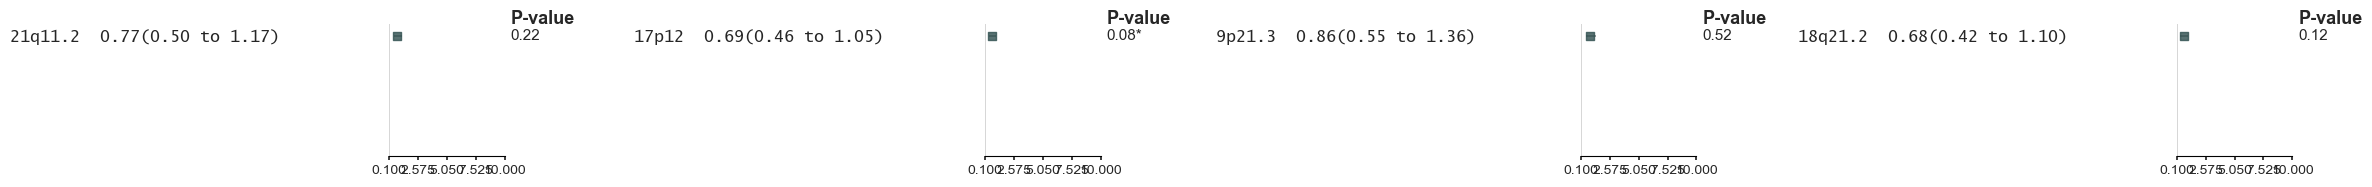

6 months:
21q11.2: p-val = 0.03, HR = 0.37
17p12: p-val = 0.02, HR = 0.27
9p21.3: p-val = 0.11, HR = 0.36
18q21.2: p-val = 0.23, HR = 0.47


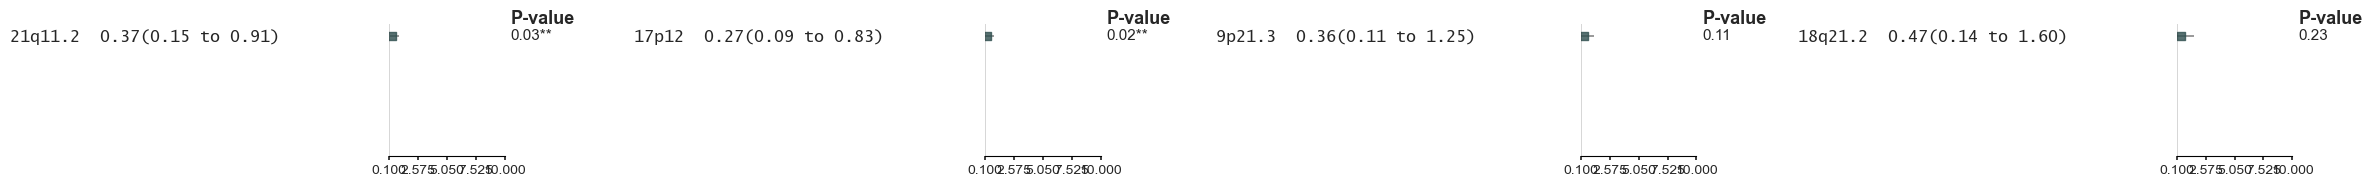

12 months:
21q11.2: p-val = 0.31, HR = 0.72
17p12: p-val = 0.08, HR = 0.56
9p21.3: p-val = 0.24, HR = 0.65
18q21.2: p-val = 0.26, HR = 0.64


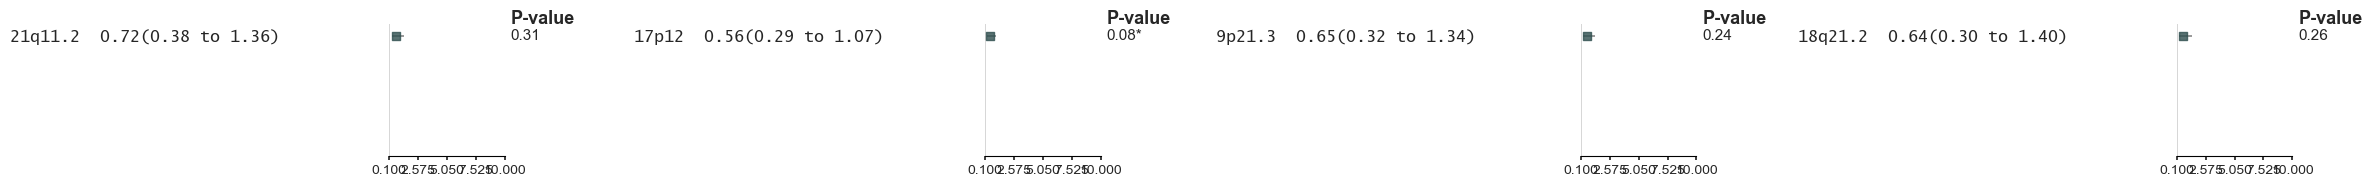

18 months:
21q11.2: p-val = 0.10, HR = 0.66
17p12: p-val = 0.01, HR = 0.52
9p21.3: p-val = 0.17, HR = 0.67
18q21.2: p-val = 0.14, HR = 0.63


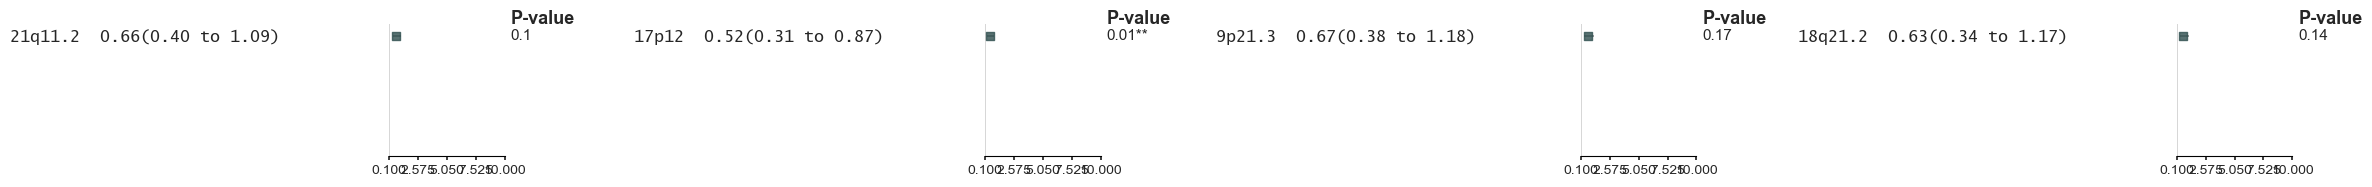

24 months:
21q11.2: p-val = 0.24, HR = 0.76
17p12: p-val = 0.30, HR = 0.79
9p21.3: p-val = 0.50, HR = 0.85
18q21.2: p-val = 0.17, HR = 0.69


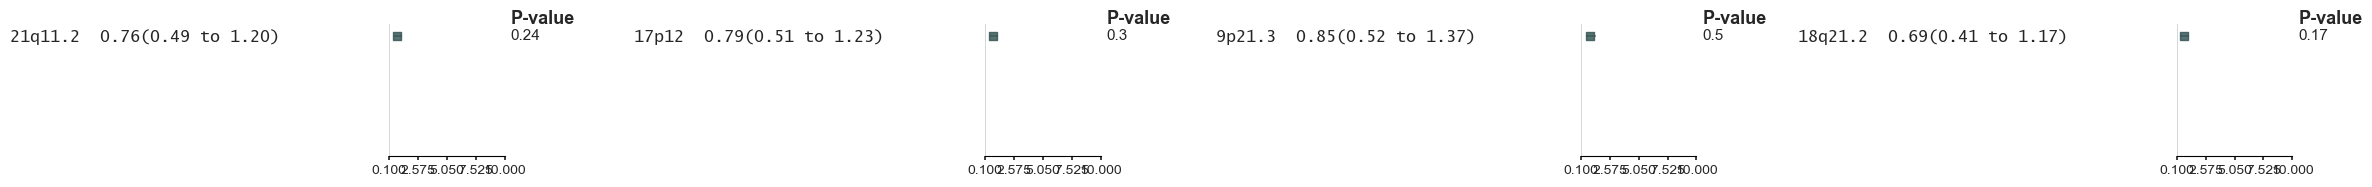

36 months:
21q11.2: p-val = 0.24, HR = 0.77
17p12: p-val = 0.12, HR = 0.71
9p21.3: p-val = 0.64, HR = 0.89
18q21.2: p-val = 0.11, HR = 0.66


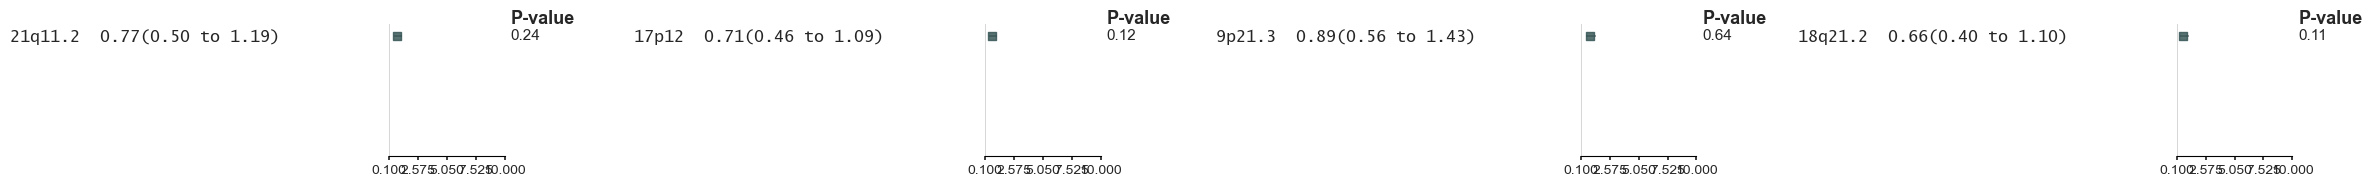

60 months:
21q11.2: p-val = 0.28, HR = 0.79
17p12: p-val = 0.11, HR = 0.71
9p21.3: p-val = 0.64, HR = 0.90
18q21.2: p-val = 0.16, HR = 0.71


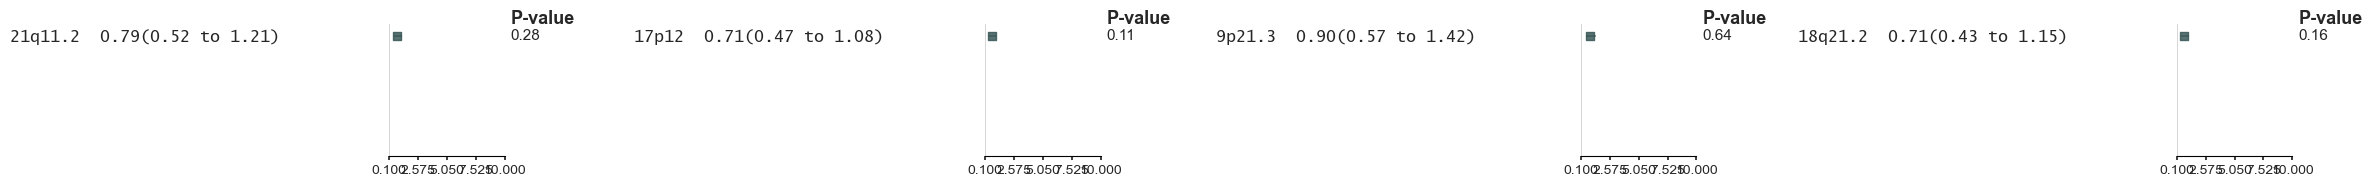

PLOTS (RECURRENCE):
Overall:
21q11.2: p-val = 0.99, HR = 1.00
17p12: p-val = 0.32, HR = 0.79
9p21.3: p-val = 0.86, HR = 0.96
18q21.2: p-val = 0.07, HR = 0.60


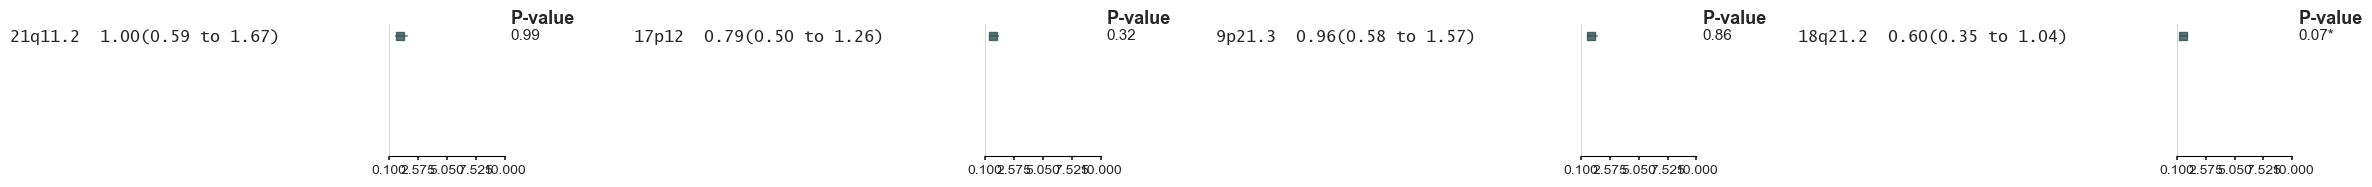

6 months:
21q11.2: p-val = 0.52, HR = 0.74
17p12: p-val = 0.14, HR = 0.50
9p21.3: p-val = 0.06, HR = 0.31
18q21.2: p-val = 0.19, HR = 0.44


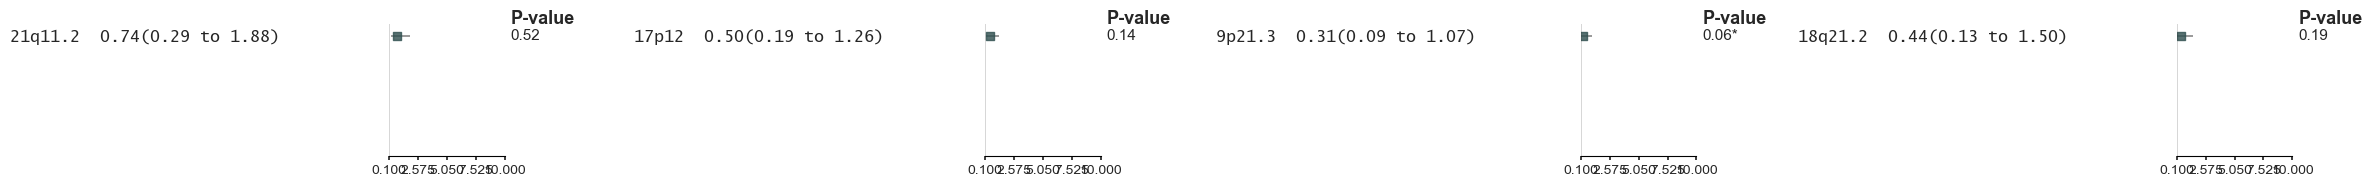

12 months:
21q11.2: p-val = 0.38, HR = 0.75
17p12: p-val = 0.19, HR = 0.66
9p21.3: p-val = 0.39, HR = 0.75
18q21.2: p-val = 0.15, HR = 0.57


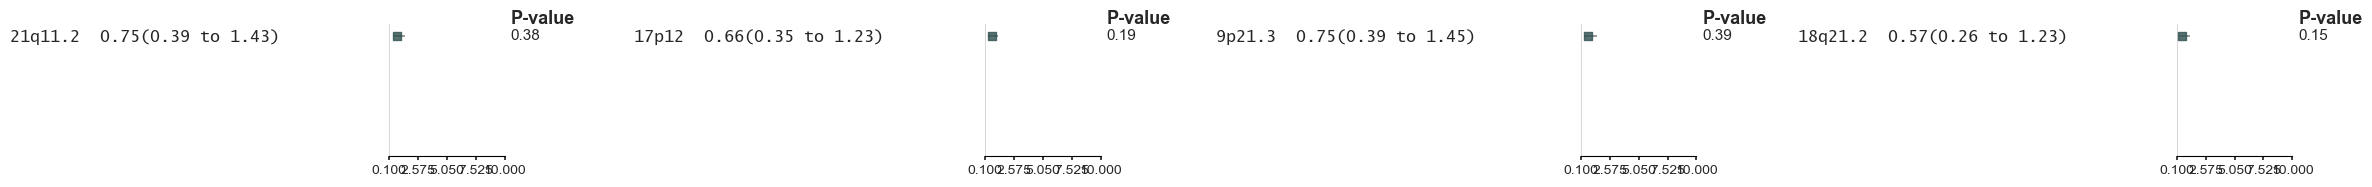

18 months:
21q11.2: p-val = 0.57, HR = 0.85
17p12: p-val = 0.14, HR = 0.68
9p21.3: p-val = 0.32, HR = 0.75
18q21.2: p-val = 0.08, HR = 0.56


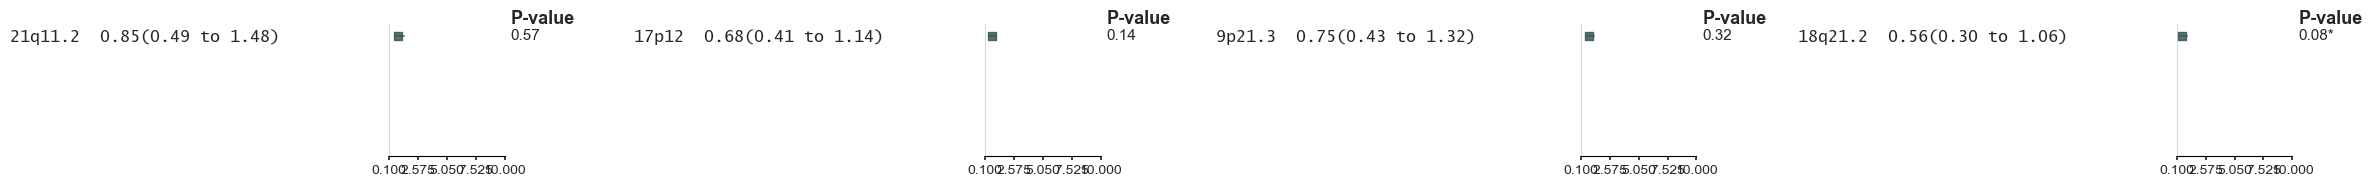

24 months:
21q11.2: p-val = 0.41, HR = 0.80
17p12: p-val = 0.18, HR = 0.72
9p21.3: p-val = 0.43, HR = 0.81
18q21.2: p-val = 0.06, HR = 0.55


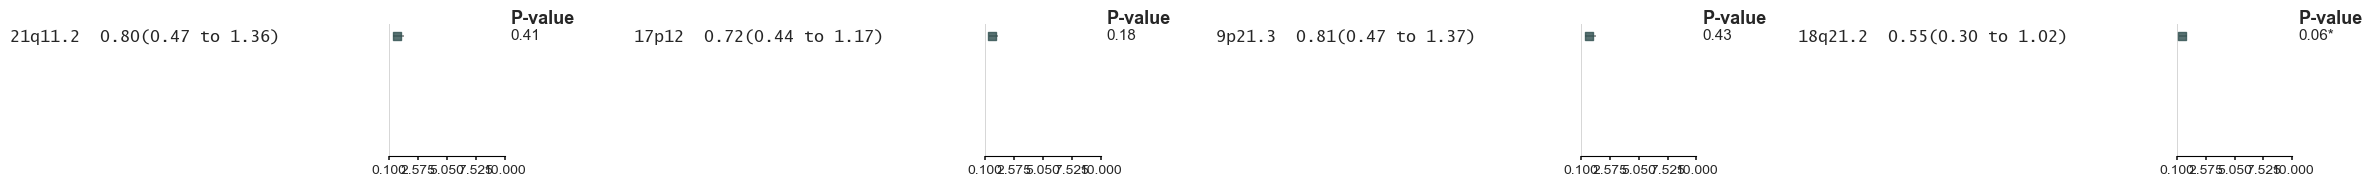

36 months:
21q11.2: p-val = 0.70, HR = 0.90
17p12: p-val = 0.19, HR = 0.73
9p21.3: p-val = 0.73, HR = 0.92
18q21.2: p-val = 0.10, HR = 0.62


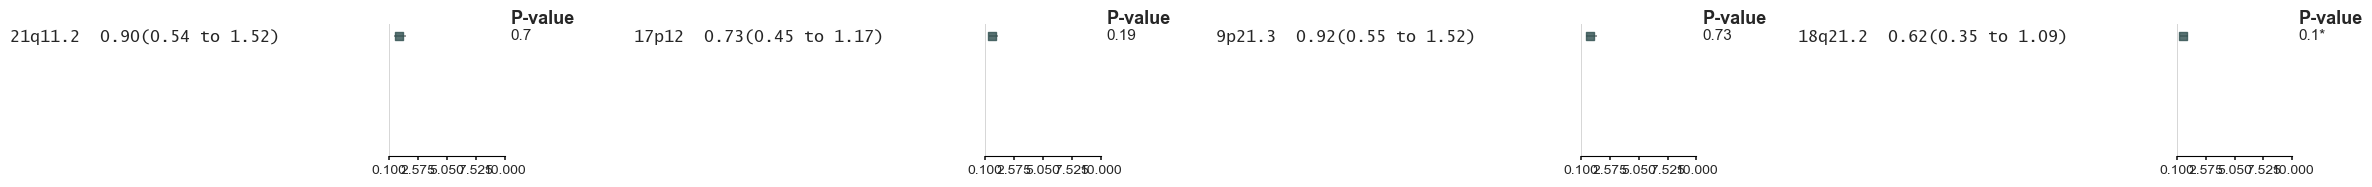

60 months:
21q11.2: p-val = 0.99, HR = 1.00
17p12: p-val = 0.32, HR = 0.79
9p21.3: p-val = 0.86, HR = 0.96
18q21.2: p-val = 0.07, HR = 0.60


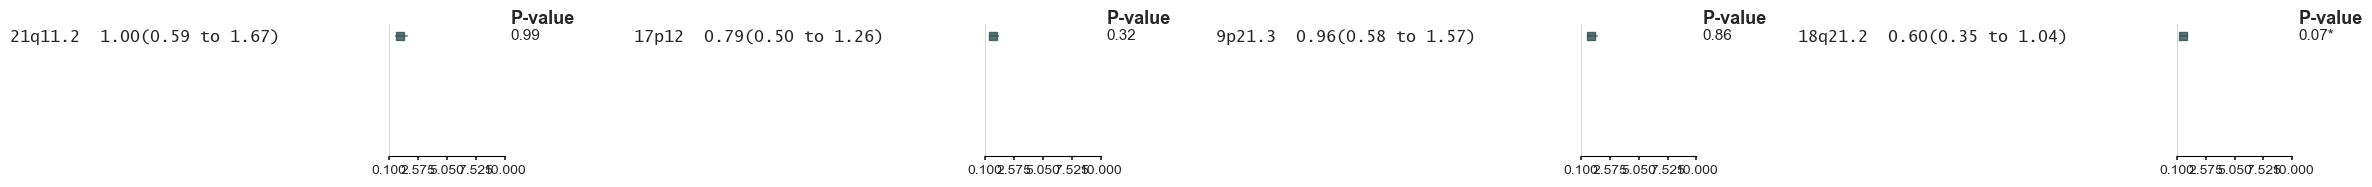

In [21]:
# COPY NUMBER SURVIVAL FEATURES
cna_data = pd.read_csv('TCGA_processed_data/CNA_processed.csv', index_col=0)
cna_data['Cluster'] = cna_data.index.map(clinical_data['Cluster'])
cna_data.dropna(subset=['Cluster'], inplace=True)
X_cna = cna_data.drop(columns='Cluster').astype(float)
y_cna = cna_data['Cluster'].astype(int)

# Matthews coefficient (all features)
crossval_cna = cross_val_score(RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced_subsample'), 
                               X_cna, y_cna, cv=skf, scoring='matthews_corrcoef')
print("MCC score: %0.4f, standard deviation: %0.4f" % (crossval_cna.mean(), crossval_cna.std()))

# Do ABESS on copy number features
pipeline_cna = make_pipeline(ABESSClassif(random_state=RANDOM_STATE), 
                             RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced_subsample', oob_score=True))
scores_cna = cross_val_score(pipeline_cna, X_cna, y_cna, cv=skf, scoring='matthews_corrcoef')
pipeline_cna.fit(X_cna, y_cna)
features_selected_cna = pipeline_cna.named_steps['abessclassif'].features_
print(f"Selected copy number features: {features_selected_cna}")
print(f"Matthews Correlation Coefficient: {scores_cna.mean():.4f}, standard deviation: {scores_cna.std():.4f}")
print(f"Out-of-bag (OOB) score: {pipeline_cna.named_steps['randomforestclassifier'].oob_score_:.4f}")

features_selected_cna = pipeline_cna.named_steps['abessclassif'].features_
selected_cna_data = X_cna[features_selected_cna]

# SURVIVAL PLOTS
print("PLOTS (SURVIVAL):")
cox_cna_survival = selected_cna_data.merge(survival_data, left_index=True, right_index=True)
print("Overall:")
fig, axes = plt.subplots(1, len(features_selected_cna), figsize=(6 * len(features_selected_cna), 2))
for i, col_idx in enumerate(features_selected_cna):
    biomarker = col_idx
    biomarker_data = cox_cna_survival[[biomarker, 'Overall Survival (Months)', 'Overall Survival Status']]
    cph = CoxPHFitter()
    summary = cph.fit(biomarker_data, duration_col='Overall Survival (Months)', event_col='Overall Survival Status').summary
    print(f"{biomarker}: p-val = {summary['p'].loc[biomarker]:.2f}, HR = {summary['exp(coef)'].loc[biomarker]:.2f}")
    summary.reset_index(inplace=True)
    ax = axes[i] if len(features_selected_cna) > 1 else axes
    fp.forestplot(summary, estimate='exp(coef)', ll='exp(coef) lower 95%', hl='exp(coef) upper 95%',
        varlabel='covariate', pval='p', color_alt_rows=True, ax=ax, title=biomarker, xticks=np.linspace(0.1, 10, 5))
plt.tight_layout()
plt.show()
for time in months:
    print(f"{time} months:")
    cox_copy = cox_cna_survival.copy()
    time_subset = cox_copy['Overall Survival (Months)'] <= time
    cox_copy.loc[~time_subset, 'Overall Survival Status'] = 0
    fig, axes = plt.subplots(1, len(features_selected_cna), figsize=(6 * len(features_selected_cna), 2))
    for i, col_idx in enumerate(features_selected_cna):
        biomarker = col_idx
        biomarker_data = cox_copy[[biomarker, 'Overall Survival (Months)', 'Overall Survival Status']]
        cph = CoxPHFitter()
        summary = cph.fit(biomarker_data, duration_col='Overall Survival (Months)', event_col='Overall Survival Status').summary
        print(f"{biomarker}: p-val = {summary['p'].loc[biomarker]:.2f}, HR = {summary['exp(coef)'].loc[biomarker]:.2f}")
        summary.reset_index(inplace=True)
        ax = axes[i] if len(features_selected_cna) > 1 else axes
        fp.forestplot(summary, estimate='exp(coef)', ll='exp(coef) lower 95%', hl='exp(coef) upper 95%',
            varlabel='covariate', pval='p', color_alt_rows=True, ax=ax, title=biomarker, xticks=np.linspace(0.1, 10, 5))
    plt.tight_layout()
    plt.show()

# RECURRENCE PLOTS
print("PLOTS (RECURRENCE):")
cox_cna_recurrence = selected_cna_data.merge(recurrence_data, left_index=True, right_index=True)
fig, axes = plt.subplots(1, len(features_selected_cna), figsize=(6 * len(features_selected_cna), 2))
print("Overall:")
for i, col_idx in enumerate(features_selected_cna):
    biomarker = col_idx
    biomarker_data = cox_cna_recurrence[[biomarker, 'Disease Free (Months)', 'Disease Free Status']]
    cph = CoxPHFitter()
    summary = cph.fit(biomarker_data, duration_col='Disease Free (Months)', event_col='Disease Free Status').summary
    print(f"{biomarker}: p-val = {summary['p'].loc[biomarker]:.2f}, HR = {summary['exp(coef)'].loc[biomarker]:.2f}")
    summary.reset_index(inplace=True)
    ax = axes[i] if len(features_selected_cna) > 1 else axes
    fp.forestplot(summary, estimate='exp(coef)', ll='exp(coef) lower 95%', hl='exp(coef) upper 95%',
        varlabel='covariate', pval='p', color_alt_rows=True, ax=ax, title=biomarker, xticks=np.linspace(0.1, 10, 5))
plt.tight_layout()
plt.show()
for time in months:
    print(f"{time} months:")
    cox_copy = cox_cna_recurrence.copy()
    time_subset = cox_copy['Disease Free (Months)'] <= time
    cox_copy.loc[~time_subset, 'Disease Free Status'] = 0
    fig, axes = plt.subplots(1, len(features_selected_cna), figsize=(6 * len(features_selected_cna), 2))
    for i, col_idx in enumerate(features_selected_cna):
        biomarker = col_idx
        biomarker_data = cox_copy[[biomarker, 'Disease Free (Months)', 'Disease Free Status']]
        cph = CoxPHFitter()
        summary = cph.fit(biomarker_data, duration_col='Disease Free (Months)', event_col='Disease Free Status').summary
        print(f"{biomarker}: p-val = {summary['p'].loc[biomarker]:.2f}, HR = {summary['exp(coef)'].loc[biomarker]:.2f}")
        summary.reset_index(inplace=True)
        ax = axes[i] if len(features_selected_cna) > 1 else axes
        fp.forestplot(summary, estimate='exp(coef)', ll='exp(coef) lower 95%', hl='exp(coef) upper 95%',
            varlabel='covariate', pval='p', color_alt_rows=True, ax=ax, title=biomarker, xticks=np.linspace(0.1, 10, 5))
    plt.tight_layout()
    plt.show()

MCC score: 0.9186, standard deviation: 0.0776
Selected multimodal features: ['cg00839579', 'cg06785999', 'cg07095230']
Matthews Correlation Coefficient: 0.7900, standard deviation: 0.0745
Out-of-bag (OOB) score: 0.9737
PLOTS (SURVIVAL):
Overall:
cg00839579: p-val = 0.23, HR = 1.73
cg06785999: p-val = 0.38, HR = 1.69
cg07095230: p-val = 0.22, HR = 2.09


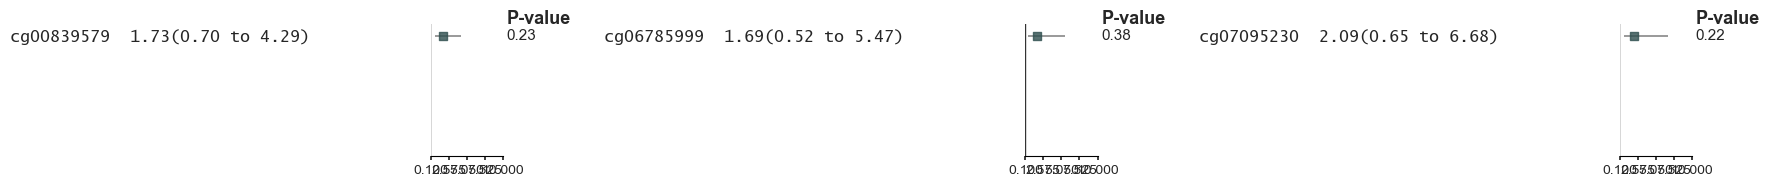

6 months:
cg00839579: p-val = 0.03, HR = 9.69
cg06785999: p-val = 0.08, HR = 8.99
cg07095230: p-val = 0.32, HR = 3.47


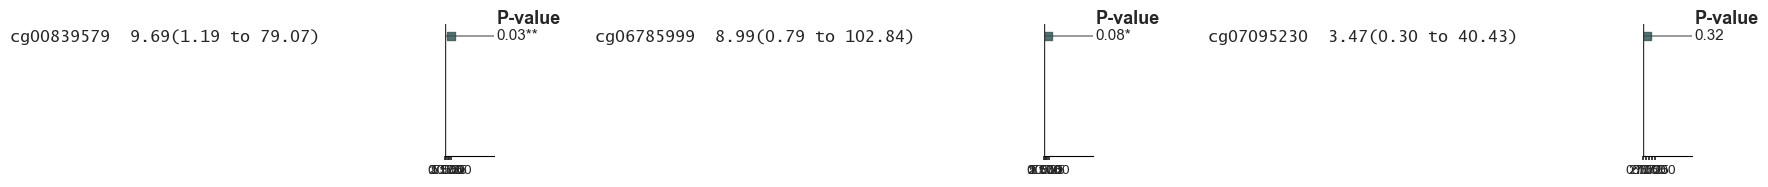

12 months:
cg00839579: p-val = 0.07, HR = 3.65
cg06785999: p-val = 0.41, HR = 2.00
cg07095230: p-val = 0.25, HR = 2.68


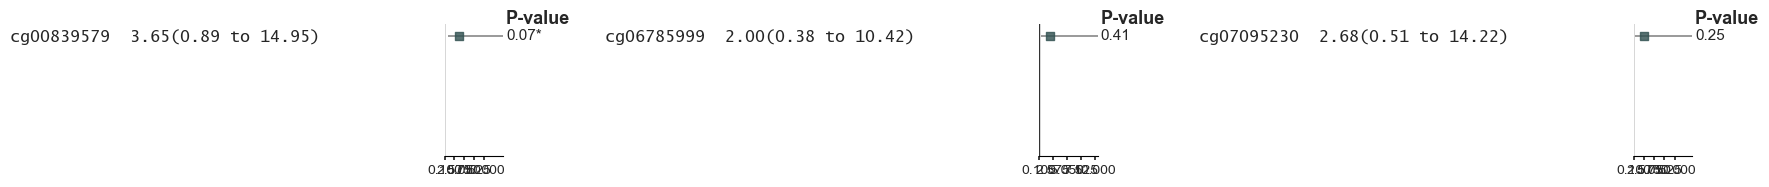

18 months:
cg00839579: p-val = 0.03, HR = 3.21
cg06785999: p-val = 0.14, HR = 2.71
cg07095230: p-val = 0.05, HR = 3.74


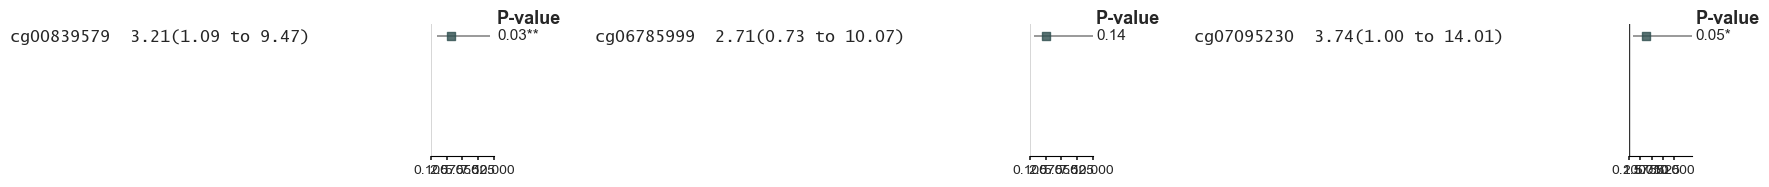

24 months:
cg00839579: p-val = 0.31, HR = 1.65
cg06785999: p-val = 0.46, HR = 1.57
cg07095230: p-val = 0.23, HR = 2.10


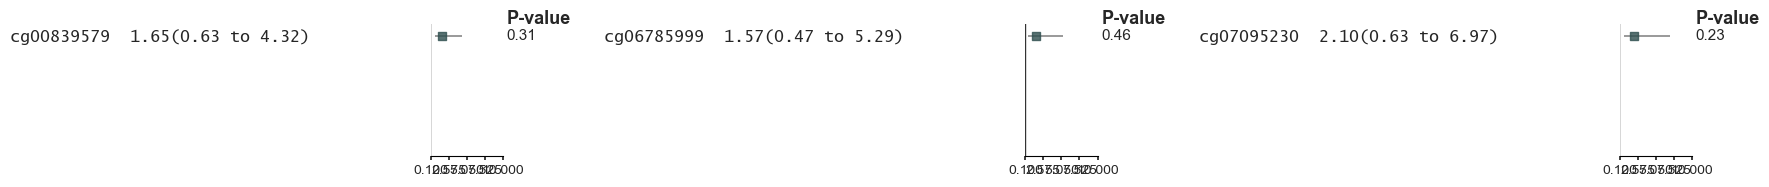

36 months:
cg00839579: p-val = 0.24, HR = 1.75
cg06785999: p-val = 0.39, HR = 1.69
cg07095230: p-val = 0.20, HR = 2.15


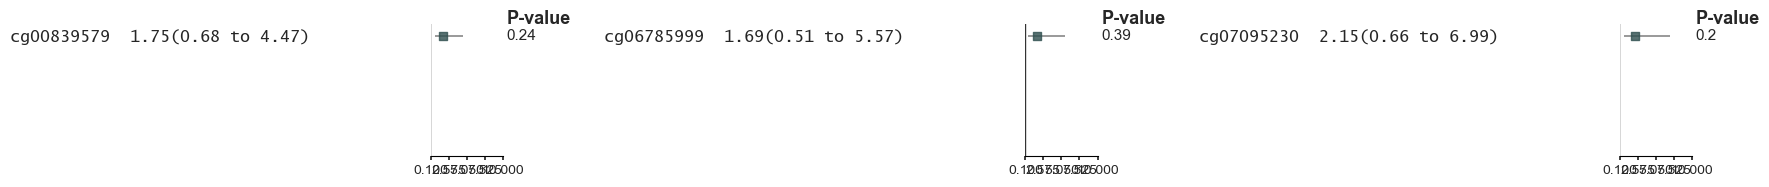

60 months:
cg00839579: p-val = 0.28, HR = 1.67
cg06785999: p-val = 0.41, HR = 1.65
cg07095230: p-val = 0.25, HR = 1.99


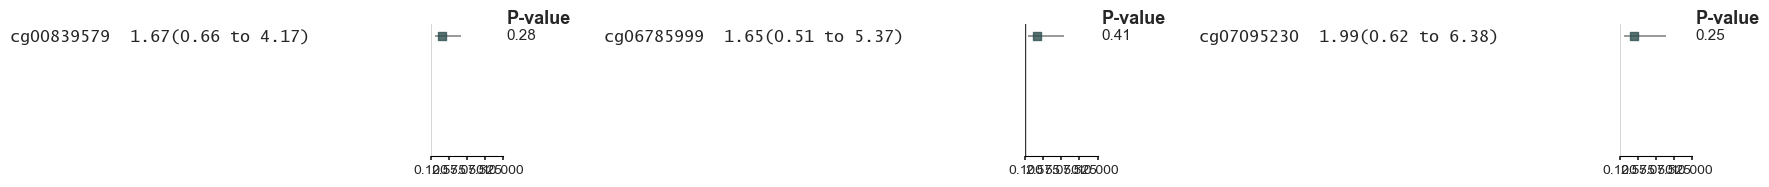

PLOTS (RECURRENCE):
Overall:
cg00839579: p-val = 0.47, HR = 1.44
cg06785999: p-val = 0.07, HR = 3.54
cg07095230: p-val = 0.12, HR = 2.85


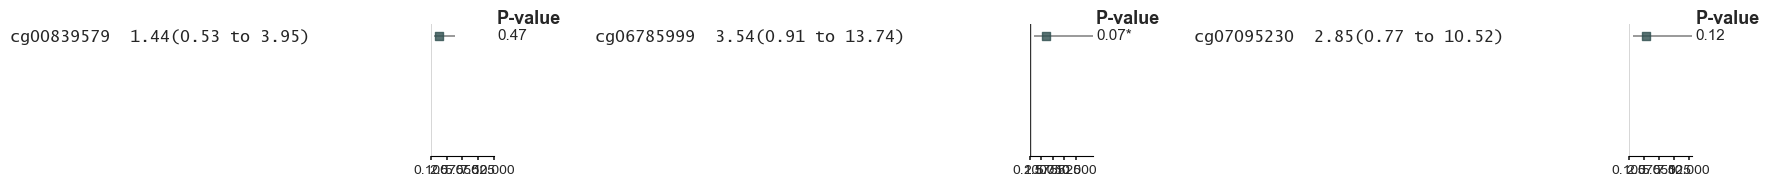

6 months:
cg00839579: p-val = 0.33, HR = 2.64
cg06785999: p-val = 0.24, HR = 4.12
cg07095230: p-val = 0.11, HR = 7.15


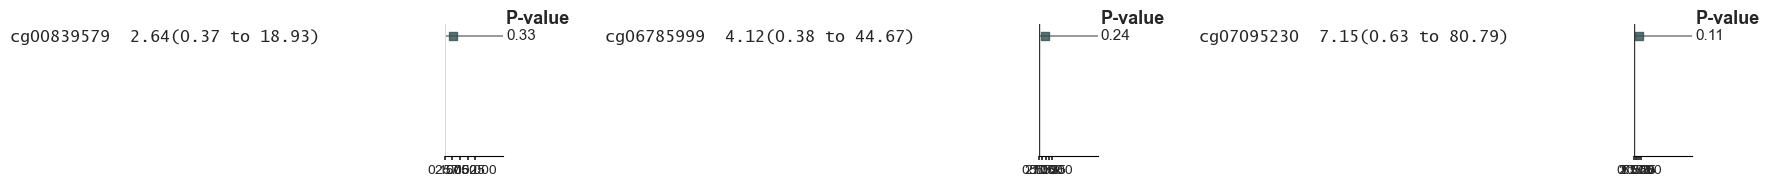

12 months:
cg00839579: p-val = 0.21, HR = 2.34
cg06785999: p-val = 0.05, HR = 5.28
cg07095230: p-val = 0.07, HR = 4.71


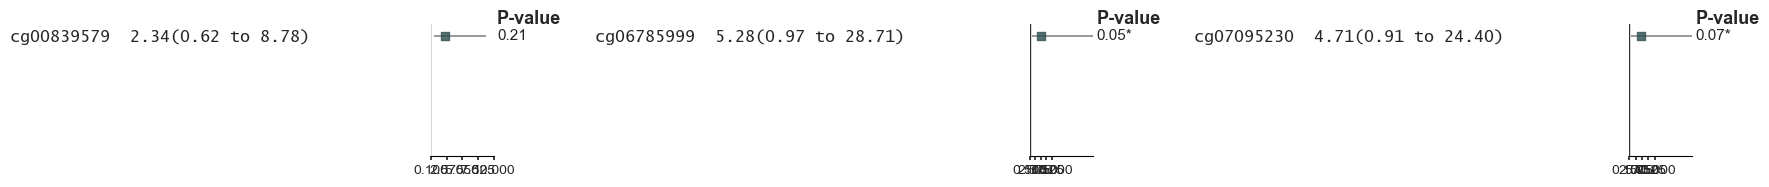

18 months:
cg00839579: p-val = 0.24, HR = 1.93
cg06785999: p-val = 0.04, HR = 4.68
cg07095230: p-val = 0.03, HR = 4.82


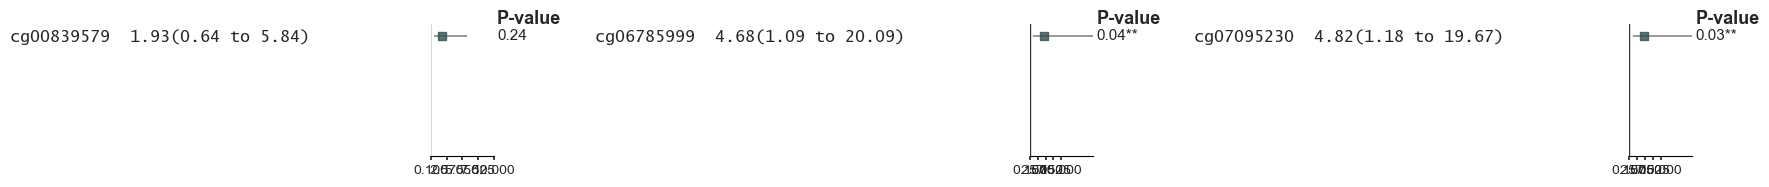

24 months:
cg00839579: p-val = 0.21, HR = 1.96
cg06785999: p-val = 0.01, HR = 5.91
cg07095230: p-val = 0.03, HR = 4.39


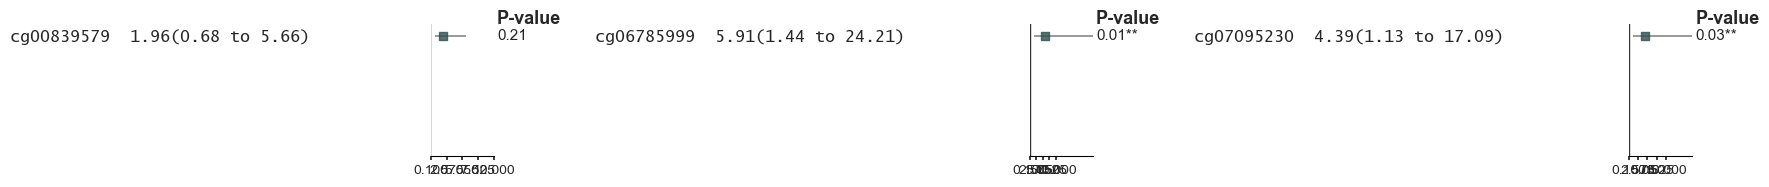

36 months:
cg00839579: p-val = 0.27, HR = 1.78
cg06785999: p-val = 0.03, HR = 4.55
cg07095230: p-val = 0.06, HR = 3.62


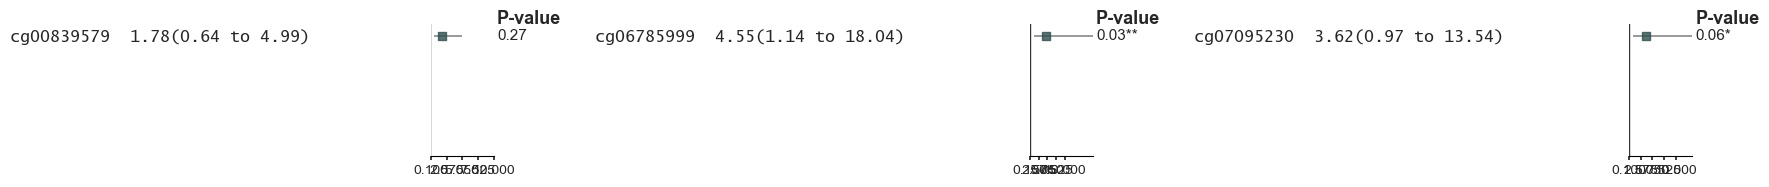

60 months:
cg00839579: p-val = 0.47, HR = 1.44
cg06785999: p-val = 0.07, HR = 3.54
cg07095230: p-val = 0.12, HR = 2.85


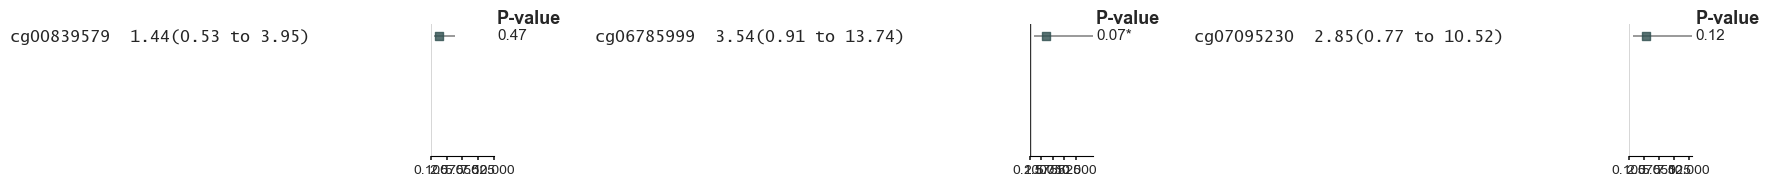

In [23]:
# ABESS WITH INTERMEDIATE FEATURE SELECTION
X_cna = pd.read_csv("TCGA_processed_data/CNA_processed.csv", index_col=0)
X_methylation = pd.read_csv("TCGA_processed_data/methylation_processed.csv", index_col=0)
combined_data = pd.concat([X_methylation, X_cna], axis=1)
combined_data.dropna(inplace=True)
combined_data['Cluster'] = combined_data.index.map(clinical_data['Cluster'])
combined_data.dropna(axis=0, inplace=True)
X_total = combined_data.drop(columns='Cluster').dropna(axis=0).astype(float)
y_total = combined_data.loc[X_total.index, 'Cluster'].astype(int)

# Matthews coefficient (all features)
crossval_total = cross_val_score(RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced_subsample'), 
                                 X_total, y_total, cv=skf, scoring='matthews_corrcoef')
print("MCC score: %0.4f, standard deviation: %0.4f" % (crossval_total.mean(), crossval_total.std()))

common_index = X_cna.index.intersection(X_methylation.index).intersection(y_total.index)
X_cna = X_cna.loc[common_index]
X_methylation = X_methylation.loc[common_index]
cna_cols = X_cna.columns
methyl_cols = X_methylation.columns
X_combined = pd.concat([X_cna, X_methylation], axis=1)

selector = MultiModalIFABESS(random_state = RANDOM_STATE)
wrapped_selector = SplitMultiModalWrapper(selector, cna_cols, methyl_cols)
pipeline_multi = make_pipeline(wrapped_selector,
                               RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced_subsample', oob_score=True))
scores_multi = cross_val_score(pipeline_multi, X_combined, y_total, cv=skf, scoring='matthews_corrcoef')
pipeline_multi.fit(X_combined, y_total)
features_selected_final = pipeline_multi.named_steps['splitmultimodalwrapper'].selector.features_
print(f"Selected multimodal features: {features_selected_final}")
print(f"Matthews Correlation Coefficient: {scores_multi.mean():.4f}, standard deviation: {scores_multi.std():.4f}")
print(f"Out-of-bag (OOB) score: {pipeline_multi.named_steps['randomforestclassifier'].oob_score_:.4f}")

# SURVIVAL PLOTS
selected_final_data = X_combined[features_selected_final]
cox_input_survival = selected_final_data.merge(survival_data, left_index=True, right_index=True)
print("PLOTS (SURVIVAL):")
print("Overall:")
fig, axes = plt.subplots(1, len(features_selected_final), figsize=(6 * len(features_selected_final), 2))
for i, col_idx in enumerate(features_selected_final):
    biomarker = col_idx
    biomarker_data = cox_input_survival[[biomarker, 'Overall Survival (Months)', 'Overall Survival Status']]
    cph = CoxPHFitter()
    summary = cph.fit(biomarker_data, duration_col='Overall Survival (Months)', event_col='Overall Survival Status').summary
    print(f"{biomarker}: p-val = {summary['p'].loc[biomarker]:.2f}, HR = {summary['exp(coef)'].loc[biomarker]:.2f}")
    summary.reset_index(inplace=True)
    ax = axes[i] if len(features_selected_final) > 1 else axes
    fp.forestplot(summary, estimate='exp(coef)', ll='exp(coef) lower 95%', hl='exp(coef) upper 95%',
        varlabel='covariate', pval='p', color_alt_rows=True, ax=ax, title=biomarker, xticks=np.linspace(0.1, 10, 5))
plt.tight_layout()
plt.show()
for time in months:
    print(f"{time} months:")
    cox_copy = cox_input_survival.copy()
    time_subset = cox_copy['Overall Survival (Months)'] <= time
    cox_copy.loc[~time_subset, 'Overall Survival Status'] = 0
    fig, axes = plt.subplots(1, len(features_selected_final), figsize=(6 * len(features_selected_final), 2))
    for i, col_idx in enumerate(features_selected_final):
        biomarker = col_idx
        biomarker_data = cox_copy[[biomarker, 'Overall Survival (Months)', 'Overall Survival Status']]
        cph = CoxPHFitter()
        summary = cph.fit(biomarker_data, duration_col='Overall Survival (Months)', event_col='Overall Survival Status').summary
        print(f"{biomarker}: p-val = {summary['p'].loc[biomarker]:.2f}, HR = {summary['exp(coef)'].loc[biomarker]:.2f}")
        summary.reset_index(inplace=True)
        ax = axes[i] if len(features_selected_final) > 1 else axes
        fp.forestplot(summary, estimate='exp(coef)', ll='exp(coef) lower 95%', hl='exp(coef) upper 95%',
            varlabel='covariate', pval='p', color_alt_rows=True, ax=ax, title=biomarker, xticks=np.linspace(0.1, 10, 5))
    plt.tight_layout()
    plt.show()

# RECURRENCE PLOTS
cox_input_recurrence = selected_final_data.merge(recurrence_data, left_index=True, right_index=True)
print("PLOTS (RECURRENCE):")
print("Overall:")
fig, axes = plt.subplots(1, len(features_selected_final), figsize=(6 * len(features_selected_final), 2))
for i, col_idx in enumerate(features_selected_final):
    biomarker = col_idx
    biomarker_data = cox_input_recurrence[[biomarker, 'Disease Free (Months)', 'Disease Free Status']]
    cph = CoxPHFitter()
    summary = cph.fit(biomarker_data, duration_col='Disease Free (Months)', event_col='Disease Free Status').summary
    print(f"{biomarker}: p-val = {summary['p'].loc[biomarker]:.2f}, HR = {summary['exp(coef)'].loc[biomarker]:.2f}")
    summary.reset_index(inplace=True)
    ax = axes[i] if len(features_selected_final) > 1 else axes
    fp.forestplot(summary, estimate='exp(coef)', ll='exp(coef) lower 95%', hl='exp(coef) upper 95%',
        varlabel='covariate', pval='p', color_alt_rows=True, ax=ax, title=biomarker, xticks=np.linspace(0.1, 10, 5))
plt.tight_layout()
plt.show()
for time in months:
    print(f"{time} months:")
    cox_copy = cox_input_recurrence.copy()
    time_subset = cox_copy['Disease Free (Months)'] <= time
    cox_copy.loc[~time_subset, 'Disease Free Status'] = 0
    fig, axes = plt.subplots(1, len(features_selected_final), figsize=(6 * len(features_selected_final), 2))
    for i, col_idx in enumerate(features_selected_final):
        biomarker = col_idx
        biomarker_data = cox_copy[[biomarker, 'Disease Free (Months)', 'Disease Free Status']]
        cph = CoxPHFitter()
        summary = cph.fit(biomarker_data, duration_col='Disease Free (Months)', event_col='Disease Free Status').summary
        print(f"{biomarker}: p-val = {summary['p'].loc[biomarker]:.2f}, HR = {summary['exp(coef)'].loc[biomarker]:.2f}")
        summary.reset_index(inplace=True)
        ax = axes[i] if len(features_selected_final) > 1 else axes
        fp.forestplot(summary, estimate='exp(coef)', ll='exp(coef) lower 95%', hl='exp(coef) upper 95%',
            varlabel='covariate', pval='p', color_alt_rows=True, ax=ax, title=biomarker, xticks=np.linspace(0.1, 10, 5))
    plt.tight_layout()
    plt.show()

MEOX2: p-val = 0.54, HR = 1.00
SIX6: p-val = 0.80, HR = 1.00
TBX2: p-val = 0.47, HR = 1.00


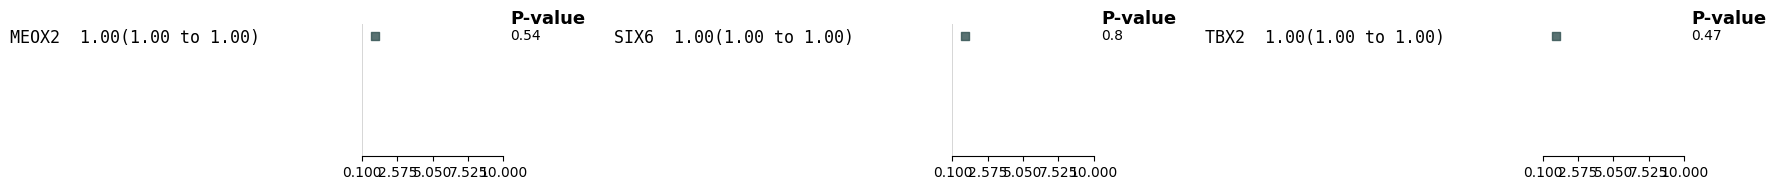

6 months:
MEOX2: p-val = 0.58, HR = 1.00
SIX6: p-val = 0.69, HR = 1.00
TBX2: p-val = 0.06, HR = 1.00


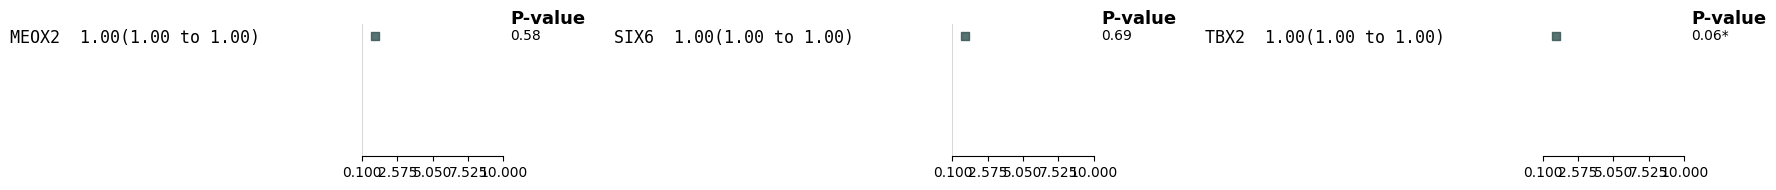

12 months:
MEOX2: p-val = 0.90, HR = 1.00
SIX6: p-val = 0.85, HR = 1.00
TBX2: p-val = 0.34, HR = 1.00


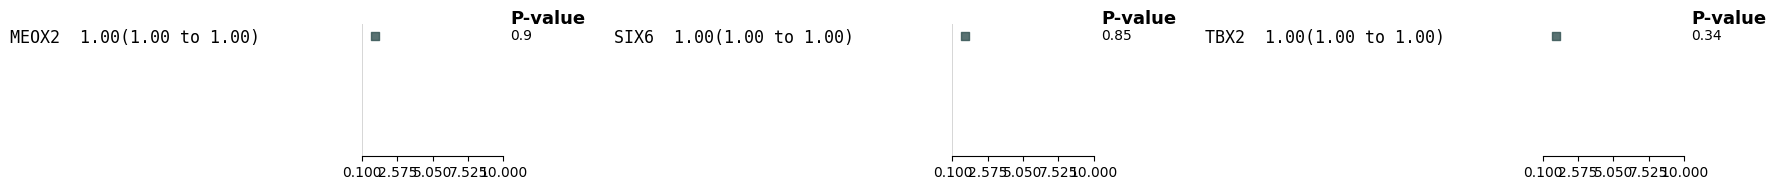

18 months:
MEOX2: p-val = 0.55, HR = 1.00
SIX6: p-val = 0.95, HR = 1.00
TBX2: p-val = 0.65, HR = 1.00


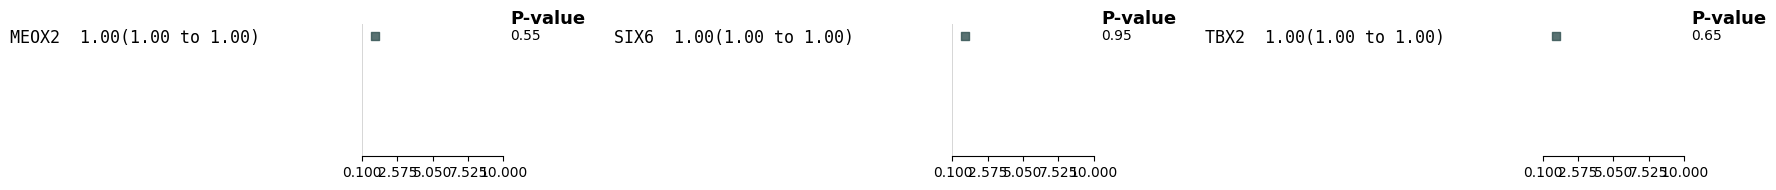

24 months:
MEOX2: p-val = 0.31, HR = 1.00
SIX6: p-val = 0.76, HR = 1.00
TBX2: p-val = 0.50, HR = 1.00


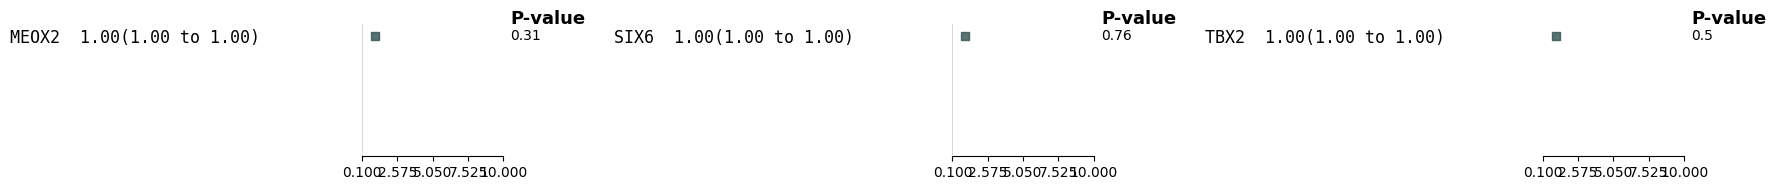

36 months:
MEOX2: p-val = 0.54, HR = 1.00
SIX6: p-val = 0.80, HR = 1.00
TBX2: p-val = 0.47, HR = 1.00


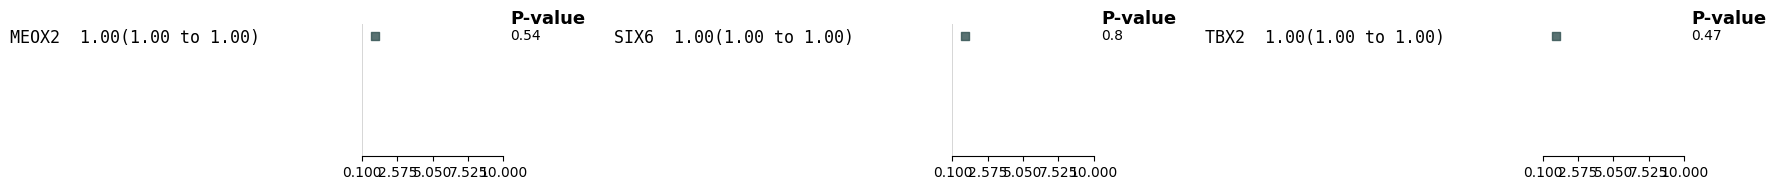

In [194]:
# VALIDATION WITH EXTERNAL DATASET
# convert features to gene (using TCGA data, needs to be uploaded)
features2genes = ['MEOX2', 'SIX6', 'TBX2']
validation_genes = pd.read_csv('CAO_RNA_genes.csv', sep=';', header=0, index_col=0).T
validation_genes.index.name = 'patient_id'
validation_clinical = pd.read_csv('CAO_data_clinical.csv', header=0, index_col='patient_id')
validation_dataset = pd.concat([validation_genes[features2genes], validation_clinical[['time', 'status']]], axis=1, join='inner')

fig, axes = plt.subplots(1, len(features2genes), figsize=(6 * len(features2genes), 2))
for i, col_idx in enumerate(features2genes):
    biomarker = col_idx
    biomarker_data = validation_dataset[[biomarker, 'time', 'status']]
    cph = CoxPHFitter()
    summary = cph.fit(biomarker_data, duration_col='time', event_col='status').summary
    print(f"{biomarker}: p-val = {summary['p'].loc[biomarker]:.2f}, HR = {summary['exp(coef)'].loc[biomarker]:.2f}")
    summary.reset_index(inplace=True)
    ax = axes[i] if len(features2genes) > 1 else axes
    fp.forestplot(summary, estimate='exp(coef)', ll='exp(coef) lower 95%', hl='exp(coef) upper 95%',
        varlabel='covariate', pval='p', color_alt_rows=True, ax=ax, title=biomarker, xticks=np.linspace(0.1, 10, 5))
plt.tight_layout()
plt.show()

months = [6, 12, 18, 24, 36] # doesn't reach 60 months
for time in months:
    print(f"{time} months:")
    cox_copy = validation_dataset.copy()
    time_subset = cox_copy['time'] <= time
    cox_copy.loc[~time_subset, 'status'] = 0
    fig, axes = plt.subplots(1, len(features2genes), figsize=(6 * len(features2genes), 2))
    for i, col_idx in enumerate(features2genes):
        biomarker = col_idx
        biomarker_data = cox_copy[[biomarker, 'time', 'status']]
        cph = CoxPHFitter()
        summary = cph.fit(biomarker_data, duration_col='time', event_col='status').summary
        print(f"{biomarker}: p-val = {summary['p'].loc[biomarker]:.2f}, HR = {summary['exp(coef)'].loc[biomarker]:.2f}")
        summary.reset_index(inplace=True)
        ax = axes[i] if len(features2genes) > 1 else axes
        fp.forestplot(summary, estimate='exp(coef)', ll='exp(coef) lower 95%', hl='exp(coef) upper 95%',
            varlabel='covariate', pval='p', color_alt_rows=True, ax=ax, title=biomarker, xticks=np.linspace(0.1, 10, 5))
    plt.tight_layout()
    plt.show()

TBX2: p-val = 0.36, HR = 1.00


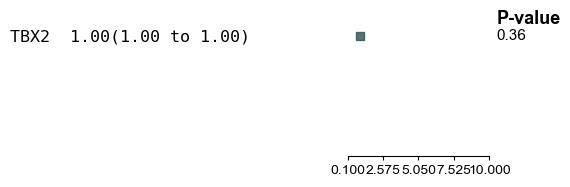

6 months:
TBX2: p-val = 0.11, HR = 1.00


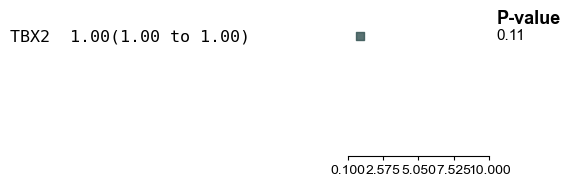

12 months:
TBX2: p-val = 0.86, HR = 1.00


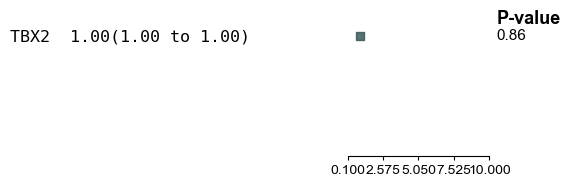

18 months:
TBX2: p-val = 0.26, HR = 1.00


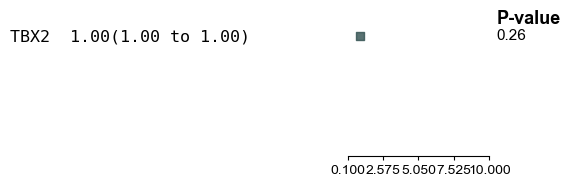

24 months:
TBX2: p-val = 0.33, HR = 1.00


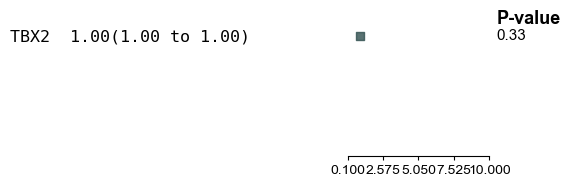

36 months:
TBX2: p-val = 0.36, HR = 1.00


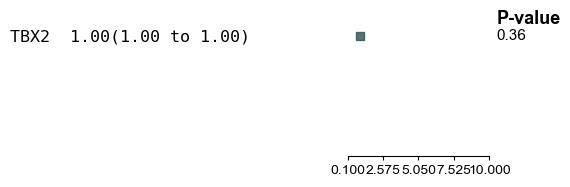

In [99]:
# VALIDATION WITH EXTERNAL DATASET
# convert features to gene (using TCGA data, needs to be uploaded)
features2genes = ['TBX2']
validation_genes = pd.read_csv('methylation data CAO.csv', sep=';', header=0, index_col=0).T
validation_genes.index.name = 'patient_id'
validation_clinical = pd.read_csv('CAO_data_clinical.csv', header=0, index_col='patient_id')
validation_dataset = pd.concat([validation_genes[features2genes], validation_clinical[['time', 'status']]], axis=1, join='inner')

fig, axes = plt.subplots(1, len(features2genes), figsize=(6 * len(features2genes), 2))
for i, col_idx in enumerate(features2genes):
    biomarker = col_idx
    biomarker_data = validation_dataset[[biomarker, 'time', 'status']]
    cph = CoxPHFitter()
    summary = cph.fit(biomarker_data, duration_col='time', event_col='status').summary
    print(f"{biomarker}: p-val = {summary['p'].loc[biomarker]:.2f}, HR = {summary['exp(coef)'].loc[biomarker]:.2f}")
    summary.reset_index(inplace=True)
    ax = axes[i] if len(features2genes) > 1 else axes
    fp.forestplot(summary, estimate='exp(coef)', ll='exp(coef) lower 95%', hl='exp(coef) upper 95%',
        varlabel='covariate', pval='p', color_alt_rows=True, ax=ax, title=biomarker, xticks=np.linspace(0.1, 10, 5))
plt.tight_layout()
plt.show()

months = [6, 12, 18, 24, 36] # doesn't reach 60 months
for time in months:
    print(f"{time} months:")
    cox_copy = validation_dataset.copy()
    time_subset = cox_copy['time'] <= time
    cox_copy.loc[~time_subset, 'status'] = 0
    fig, axes = plt.subplots(1, len(features2genes), figsize=(6 * len(features2genes), 2))
    for i, col_idx in enumerate(features2genes):
        biomarker = col_idx
        biomarker_data = cox_copy[[biomarker, 'time', 'status']]
        cph = CoxPHFitter()
        summary = cph.fit(biomarker_data, duration_col='time', event_col='status').summary
        print(f"{biomarker}: p-val = {summary['p'].loc[biomarker]:.2f}, HR = {summary['exp(coef)'].loc[biomarker]:.2f}")
        summary.reset_index(inplace=True)
        ax = axes[i] if len(features2genes) > 1 else axes
        fp.forestplot(summary, estimate='exp(coef)', ll='exp(coef) lower 95%', hl='exp(coef) upper 95%',
            varlabel='covariate', pval='p', color_alt_rows=True, ax=ax, title=biomarker, xticks=np.linspace(0.1, 10, 5))
    plt.tight_layout()
    plt.show()